<a href="https://colab.research.google.com/github/ZainabKhan77/ADS2-term-paper/blob/main/TermPaper_ZainabKhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Table: Summary Statistics

|                        |   n|  mean|    sd| median|   min|    max|
|:-----------------------|---:|-----:|-----:|------:|-----:|------:|
|net_profit_margin       | 163|  0.31|  0.18|   0.29| -0.04|   0.78|
|rd_expenditure          | 163| 67.59| 26.75|  63.84| 20.68| 116.20|
|marketing_spend         | 163| 67.18| 26.45|  63.95|  9.43| 116.74|
|employee_satisfaction   | 163| 62.15| 24.31|  58.52| 13.40| 113.62|
|debt_ratio              | 163| 57.20| 22.36|  56.56| 16.22| 101.41|
|supply_chain_efficiency | 163| 73.81| 31.43|  69.22| 12.44| 128.66|
|market_share            | 163| 62.13| 24.45|  61.33| 16.53| 105.93|
|brand_value             | 163| 74.37| 28.45|  70.56| 23.22| 125.52|
|energy_costs            | 163| 56.25| 22.14|  53.83| 10.57|  98.14|
|tax_rate                | 163| 59.77| 23.71|  56.67| 14.91| 103.88|
|patent_activity         | 163| 60.92| 24.81|  58.03| 11.28| 107.29|



Table: Correlation Matrix

|                        |net_profit_margin |rd_expenditure |marketing_spend |employee_satisfaction |debt_ratio |supply_chain_efficiency |market_share |brand_value |energy_costs |tax_rate |patent_activity |
|:-----------------------|:-----------------|:--------------|:---------------|:---------------------|:----------|:-----------------------|:------------|:-----------|:------------|:--------|:---------------|
|net_profit_margin       |1***              |0.7***         |0.69***         |0.67***               |0.68***    |0.69***                 |0.68***      |0.67***     |0.67***      |0.68***  |0.65***         |
|rd_expenditure          |0.7***            |1***           |0.98***         |0.98***               |0.97***    |0.98***                 |0.98***      |0.98***     |0.98***      |0.98***  |0.97***         |
|marketing_spend         |0.69***           |0.98***        |1***            |0.98***               |0.97***    |0.98***                 |0.98*

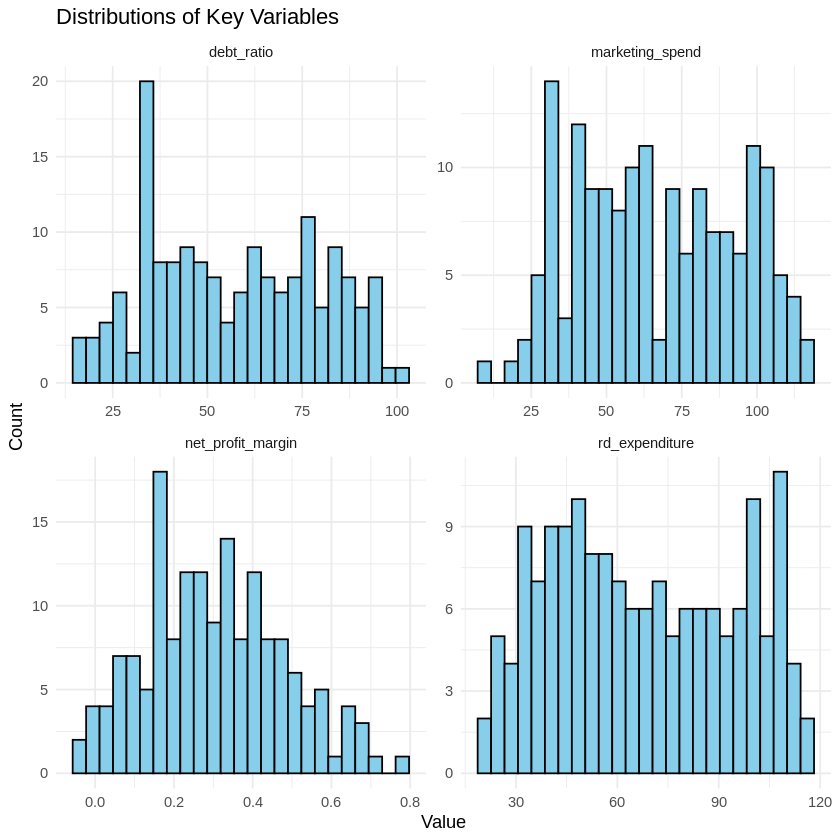


Panel Regression Results
                                             Dependent variable:                      
                        --------------------------------------------------------------
                                              net_profit_margin                       
                               Pooled OLS            Fixed Effects      Random Effects
--------------------------------------------------------------------------------------
rd_expenditure                  0.007**                 0.008***           0.007***   
                                (0.003)                 (0.003)            (0.003)    
                                                                                      
marketing_spend                  0.002                   0.002              0.002     
                                (0.003)                 (0.003)            (0.003)    
                                                                                      
employee_satisfac


t test of coefficients:

                           Estimate  Std. Error t value Pr(>|t|)  
(Intercept)              0.01114507  0.02435466  0.4576  0.64788  
rd_expenditure           0.00659987  0.00355168  1.8582  0.06507 .
marketing_spend          0.00218796  0.00190028  1.1514  0.25138  
employee_satisfaction   -0.00353645  0.00254642 -1.3888  0.16693  
debt_ratio               0.00176017  0.00208267  0.8451  0.39936  
supply_chain_efficiency  0.00282341  0.00181671  1.5541  0.12223  
market_share             0.00091909  0.00213486  0.4305  0.66743  
brand_value             -0.00203447  0.00252803 -0.8048  0.42221  
energy_costs            -0.00078520  0.00229062 -0.3428  0.73223  
tax_rate                 0.00025383  0.00277098  0.0916  0.92713  
patent_activity         -0.00434932  0.00183102 -2.3753  0.01878 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



t test of coefficients:

                           Estimate  Std. Error t value Pr(>|t|)  
rd_expenditure           7.8554e-03  3.5967e-03  2.1841  0.03065 *
marketing_spend          2.0785e-03  1.7893e-03  1.1616  0.24739  
employee_satisfaction   -3.1578e-03  2.6555e-03 -1.1891  0.23642  
debt_ratio               2.5767e-03  2.0546e-03  1.2541  0.21192  
supply_chain_efficiency  3.0123e-03  2.2063e-03  1.3653  0.17438  
market_share             1.1244e-03  2.2468e-03  0.5004  0.61757  
brand_value             -1.5543e-03  2.6549e-03 -0.5854  0.55921  
energy_costs             3.7162e-05  2.6280e-03  0.0141  0.98874  
tax_rate                 3.3001e-04  2.9742e-03  0.1110  0.91181  
patent_activity         -3.5712e-03  2.0364e-03 -1.7537  0.08170 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



	F test for individual effects

data:  form
F = 0.62878, df1 = 14, df2 = 138, p-value = 0.8375
alternative hypothesis: significant effects



	Hausman Test

data:  form
chisq = 4.3195, df = 10, p-value = 0.9318
alternative hypothesis: one model is inconsistent




Table: Hausman Test Summary

| Statistic|p_value |Preferred_Model |
|---------:|:-------|:---------------|
|      4.32|0.932   |Random Effects  |

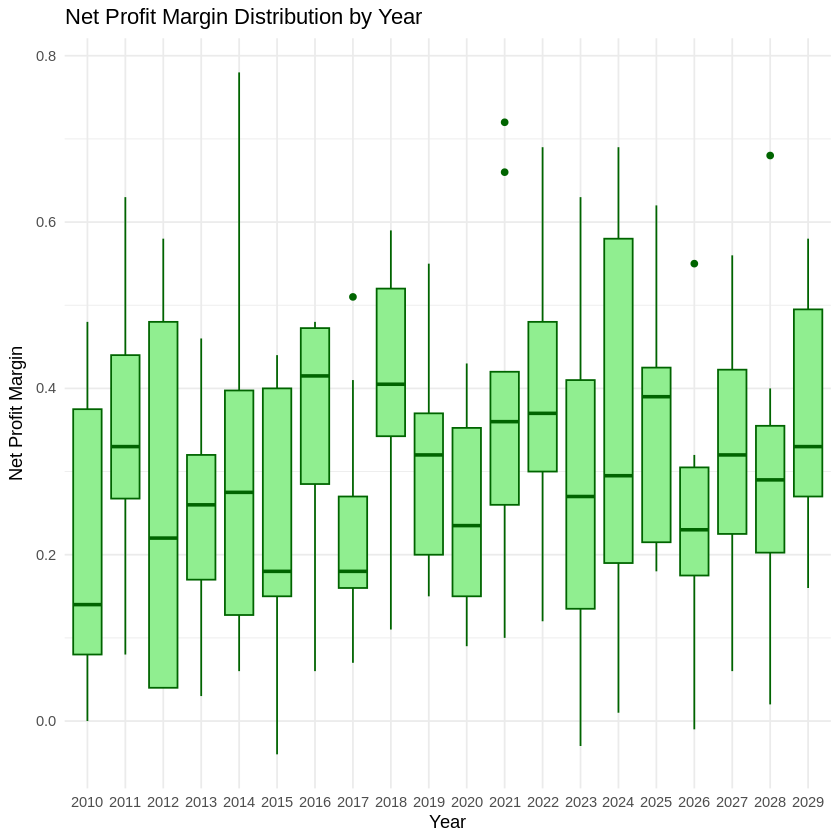

In [13]:
library(plm)
library(ggplot2)
library(stargazer)
library(psych)
library(corrplot)
library(lmtest)
library(sandwich)
library(tidyverse)
library(knitr)

# load data
df <- read.csv("Case2_Variation6_Corporate.xlsx - Data.csv", stringsAsFactors = FALSE)

# clean european decimal formatting (commas to dots)
clean_num <- function(x) {
  if (is.character(x)) {
    as.numeric(gsub(",", ".", trimws(x)))
  } else {
    x
  }
}

df <- df %>% mutate(across(rd_expenditure:net_profit_margin, clean_num))

# drop NAs to keep sample size consistent
df_clean <- na.omit(df)

# --- DESCRIPTIVE STATS & EDA ---

# summary stats table
summary_stats <- df_clean %>%
  select(net_profit_margin, rd_expenditure, marketing_spend,
         employee_satisfaction, debt_ratio, supply_chain_efficiency,
         market_share, brand_value, energy_costs, tax_rate, patent_activity) %>%
  describe() %>%
  as.data.frame() %>%
  select(n, mean, sd, median, min, max) %>%
  mutate(across(where(is.numeric), ~round(., 2)))

kable(summary_stats, caption = "Summary Statistics")

# correlation matrix
cor_vars <- df_clean %>%
  select(net_profit_margin, rd_expenditure, marketing_spend,
         employee_satisfaction, debt_ratio, supply_chain_efficiency,
         market_share, brand_value, energy_costs, tax_rate, patent_activity)

cor_matrix <- cor(cor_vars, use = "complete.obs") %>% round(2)
cor_p_values <- cor.mtest(cor_vars)$p

add_stars <- function(cor_val, p_val) {
  if (is.na(p_val)) return(as.character(cor_val))
  if (p_val < 0.001) return(paste0(cor_val, "***"))
  if (p_val < 0.01)  return(paste0(cor_val, "**"))
  if (p_val < 0.05)  return(paste0(cor_val, "*"))
  return(as.character(cor_val))
}

cor_matrix_stars <- mapply(add_stars, cor_matrix, cor_p_values)
cor_matrix_stars <- matrix(cor_matrix_stars, nrow = nrow(cor_matrix))
rownames(cor_matrix_stars) <- colnames(cor_matrix_stars) <- colnames(cor_matrix)

kable(cor_matrix_stars, caption = "Correlation Matrix")

# plots
# 1. variable distributions
df_clean %>%
  select(net_profit_margin, rd_expenditure, marketing_spend, debt_ratio) %>%
  pivot_longer(cols = everything(), names_to = "Variable", values_to = "Value") %>%
  ggplot(aes(x = Value)) +
  facet_wrap(~ Variable, scales = "free") +
  geom_histogram(bins = 25, fill = "skyblue", color = "black") +
  theme_minimal() +
  labs(title = "Distributions of Key Variables", x = "Value", y = "Count")

# 2. net profit margin across years
ggplot(df_clean, aes(x = as.factor(year), y = net_profit_margin)) +
  geom_boxplot(fill = "lightgreen", color = "darkgreen") +
  theme_minimal() +
  labs(title = "Net Profit Margin Distribution by Year", x = "Year", y = "Net Profit Margin")

# --- PANEL MODELS & DIAGNOSTICS ---

# set panel structure
pdata <- pdata.frame(df_clean, index = c("unit", "year"))

# model formula
form <- net_profit_margin ~ rd_expenditure + marketing_spend +
        employee_satisfaction + debt_ratio + supply_chain_efficiency +
        market_share + brand_value + energy_costs + tax_rate + patent_activity

# fit pooled OLS, FE, and RE models
mod_pooled <- plm(form, data = pdata, model = "pooling")
mod_fe     <- plm(form, data = pdata, model = "within")
mod_re     <- plm(form, data = pdata, model = "random")

# regression comparison table
stargazer(mod_pooled, mod_fe, mod_re,
          type = "text",
          column.labels = c("Pooled OLS", "Fixed Effects", "Random Effects"),
          digits = 3,
          title = "Panel Regression Results",
          model.numbers = FALSE)

# robust standard errors
coeftest(mod_pooled, vcov = vcovHC(mod_pooled, type = "HC1"))
coeftest(mod_fe, vcov = vcovHC(mod_fe, type = "HC1"))

# model selection tests
# 1. pooled OLS vs fixed effects
pFtest(mod_fe, mod_pooled)

# 2. hausman test (FE vs RE)
hausman_out <- phtest(mod_fe, mod_re)
hausman_out

# quick summary table for hausman output
hausman_df <- data.frame(
  Statistic = round(as.numeric(hausman_out$statistic), 2),
  p_value = format.pval(hausman_out$p.value, digits = 3),
  Preferred_Model = ifelse(hausman_out$p.value < 0.05, "Fixed Effects", "Random Effects")
)
kable(hausman_df, caption = "Hausman Test Summary")